In [1]:
import importlib.util
import random
from collections import defaultdict

import numpy as np
import torch
from pathlib import Path
from tqdm.auto import tqdm

MODEL = "16_18052026"

_spec = importlib.util.spec_from_file_location('pocket_model', f'./models/{MODEL}.py')
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

PocketFinder       = _mod.PocketFinder
parse_mol2_protein = _mod.parse_mol2_protein
parse_mol2_coords  = _mod.parse_mol2_coords

In [2]:
CHECKPOINT = f'./models/{MODEL}.pt'  # update when new model is trained

state    = torch.load(CHECKPOINT, map_location='cpu')
in_dim   = state['embedding.weight'].shape[1]
hidden   = state['embedding.weight'].shape[0]
n_layers = sum(1 for k in state if k.startswith('convs.') and k.endswith('.eps'))

model = PocketFinder(in_dim=in_dim, hidden=hidden, n_layers=n_layers)
model.load_state_dict(state)
model.eval()
print(f'loaded: in_dim={in_dim}  hidden={hidden}  n_layers={n_layers}  '
      f'params={sum(p.numel() for p in model.parameters())}')

loaded: in_dim=20  hidden=256  n_layers=4  params=544065


In [3]:
SCPDB_DIR      = Path('./data/scPDB')
DIST_THRESHOLD = 1.0
PROB_THRESHOLD = 0.6
BETA           = 2.0   # F-beta weight matching training

# ── replicate exact test split from split_dataset(seed=42, test_frac=0.1) ──
all_entries = sorted(
    d for d in SCPDB_DIR.iterdir()
    if (d / 'protein.mol2').exists() and (d / 'site.mol2').exists()
)
random.seed(42)
pdb_groups = defaultdict(list)
for i, entry in enumerate(all_entries):
    pdb_groups[entry.name[:4]].append(i)
pdb_ids = list(pdb_groups.keys())
random.shuffle(pdb_ids)
n_test   = int(0.1 * len(pdb_ids))
test_ids = set(pdb_ids[:n_test])
entries  = [all_entries[i] for pdb_id in test_ids for i in pdb_groups[pdb_id]]
print(f'{len(entries)} test entries  ({len(all_entries)} total)')

total_tp = total_fp = total_fn = 0
per_f1 = []
per_f2 = []
all_probs       = []
all_labels      = []
all_min_dists   = []
pocket_pos_list = []

with torch.no_grad():
    for entry in tqdm(entries):
        try:
            pos, h = parse_mol2_protein(entry / 'protein.mol2')
            site   = parse_mol2_coords(entry / 'site.mol2')
        except Exception:
            continue
        if len(pos) == 0:
            continue

        min_dists = torch.cdist(pos, site).min(dim=1).values
        labels    = (min_dists < DIST_THRESHOLD).float()
        batch     = torch.zeros(len(pos), dtype=torch.long)
        probs     = model(h, pos, batch).sigmoid()
        preds     = (probs > PROB_THRESHOLD).float()

        all_probs.append(probs)
        all_labels.append(labels)
        all_min_dists.append(min_dists)
        pocket_pos_list.append(pos[preds == 1].numpy())

        tp = (preds * labels).sum().item()
        fp = (preds * (1 - labels)).sum().item()
        fn = ((1 - preds) * labels).sum().item()
        total_tp += tp; total_fp += fp; total_fn += fn

        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        per_f1.append(2 * p * r / (p + r + 1e-8))
        per_f2.append((1 + BETA**2) * p * r / (BETA**2 * p + r + 1e-8))

all_probs     = torch.cat(all_probs).numpy()
all_labels    = torch.cat(all_labels).numpy()
all_min_dists = torch.cat(all_min_dists).numpy()
print(f'done — {len(per_f1)} entries evaluated')

1752 test entries  (17594 total)


  0%|          | 0/1752 [00:00<?, ?it/s]

done — 1752 entries evaluated


In [4]:
micro_p  = total_tp / (total_tp + total_fp + 1e-8)
micro_r  = total_tp / (total_tp + total_fn + 1e-8)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-8)
micro_f2 = (1 + BETA**2) * micro_p * micro_r / (BETA**2 * micro_p + micro_r + 1e-8)

print(f'entries evaluated : {len(per_f1)}')
print()
print(f'micro precision : {micro_p:.3f}')
print(f'micro recall    : {micro_r:.3f}')
print(f'micro F1        : {micro_f1:.3f}')
print(f'micro F{BETA:.0f}        : {micro_f2:.3f}')
print()
print(f'macro F1 (mean)   : {sum(per_f1)/len(per_f1):.3f}')
print(f'macro F1 (median) : {sorted(per_f1)[len(per_f1)//2]:.3f}')
print(f'macro F{BETA:.0f} (mean)   : {sum(per_f2)/len(per_f2):.3f}')
print(f'macro F{BETA:.0f} (median) : {sorted(per_f2)[len(per_f2)//2]:.3f}')
print()
print(f'total TP={int(total_tp)}  FP={int(total_fp)}  FN={int(total_fn)}')

entries evaluated : 1752

micro precision : 0.334
micro recall    : 0.688
micro F1        : 0.450
micro F2        : 0.568

macro F1 (mean)   : 0.476
macro F1 (median) : 0.481
macro F2 (mean)   : 0.567
macro F2 (median) : 0.593

total TP=40031  FP=79743  FN=18162


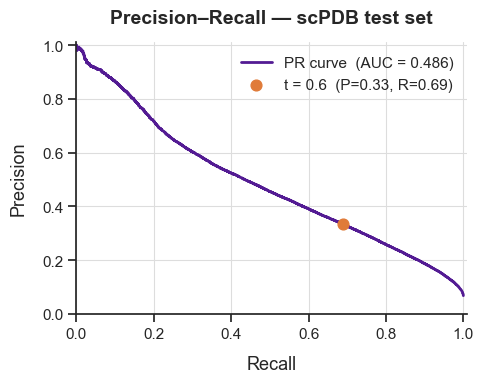

best-F1 threshold : 0.738  P=0.424  R=0.551  F1=0.479
best-F2 threshold : 0.545  P=0.306  R=0.732  F2=0.573


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall, precision)

idx_thresh = np.argmin(np.abs(thresholds - PROB_THRESHOLD))

COLOR_CURVE  = "#531B93"
COLOR_MARKER = "#E07B39"

sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(recall, precision, color=COLOR_CURVE, lw=2,
        label=f"PR curve  (AUC = {pr_auc:.3f})")
ax.scatter(recall[idx_thresh], precision[idx_thresh],
           color=COLOR_MARKER, s=60, zorder=5,
           label=f"t = {PROB_THRESHOLD}  (P={precision[idx_thresh]:.2f}, R={recall[idx_thresh]:.2f})")

ax.set_xlabel("Recall", fontsize=13, labelpad=10)
ax.set_ylabel("Precision", fontsize=13, labelpad=10)
ax.set_title("Precision–Recall — scPDB test set", fontsize=14, fontweight="bold", pad=14)
ax.set_xlim(0, 1.01)
ax.set_ylim(0, 1.01)
ax.tick_params(labelsize=11)
ax.legend(frameon=False, fontsize=11)
ax.grid(axis="both", color="#dddddd", linewidth=0.8, zorder=0)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("figs/pr_curve.svg", format="svg", bbox_inches="tight")
plt.show()

p, r = precision[:-1], recall[:-1]

f1_scores = 2 * p * r / (p + r + 1e-8)
best_f1_idx = f1_scores.argmax()
print(f"best-F1 threshold : {thresholds[best_f1_idx]:.3f}  "
      f"P={p[best_f1_idx]:.3f}  R={r[best_f1_idx]:.3f}  F1={f1_scores[best_f1_idx]:.3f}")

f2_scores = (1 + BETA**2) * p * r / (BETA**2 * p + r + 1e-8)
best_f2_idx = f2_scores.argmax()
print(f"best-F2 threshold : {thresholds[best_f2_idx]:.3f}  "
      f"P={p[best_f2_idx]:.3f}  R={r[best_f2_idx]:.3f}  F2={f2_scores[best_f2_idx]:.3f}")

In [6]:
# threshold table: for each recall target, find the operating point
print(f"{'recall':>8}  {'precision':>10}  {'F1':>7}  {'threshold':>10}")
print('-' * 44)
for target_recall in np.arange(0.50, 1.01, 0.05):
    # last index where recall >= target (recall is decreasing as threshold increases)
    idx = np.searchsorted(-recall, -target_recall)
    if idx >= len(thresholds):
        continue
    p, r, t = precision[idx], recall[idx], thresholds[idx]
    f1 = 2 * p * r / (p + r + 1e-8)
    print(f"{r:>8.3f}  {p:>10.3f}  {f1:>7.3f}  {t:>10.3f}")

  recall   precision       F1   threshold
--------------------------------------------
   0.500       0.455    0.477       0.774
   0.550       0.424    0.479       0.739
   0.600       0.391    0.473       0.695
   0.650       0.359    0.462       0.644
   0.700       0.327    0.446       0.586
   0.750       0.294    0.422       0.519
   0.800       0.258    0.391       0.443
   0.850       0.223    0.354       0.362
   0.900       0.187    0.310       0.269
   0.950       0.145    0.251       0.161
   1.000       0.068    0.127       0.000


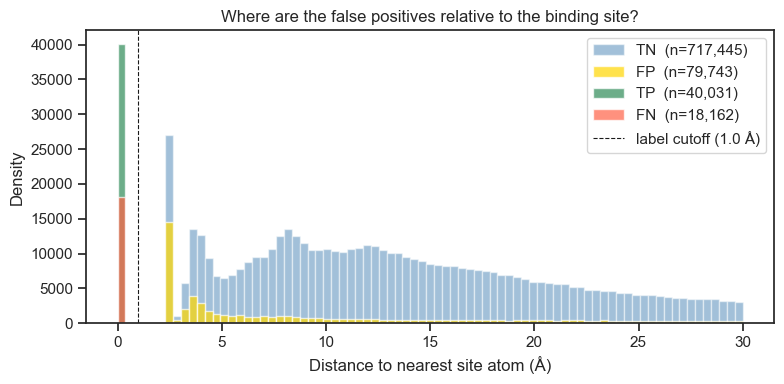

FP residues within X Å of the site:
  <  2 Å : 0.0%
  <  4 Å : 28.4%
  <  6 Å : 37.5%
  <  8 Å : 44.0%
  < 10 Å : 49.3%


In [7]:
import matplotlib.pyplot as plt

preds    = all_probs > PROB_THRESHOLD
fp_dists = all_min_dists[(preds == 1) & (all_labels == 0)]
tp_dists = all_min_dists[(preds == 1) & (all_labels == 1)]
tn_dists = all_min_dists[(preds == 0) & (all_labels == 0)]
fn_dists = all_min_dists[(preds == 0) & (all_labels == 1)]

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 30, 80)
for dists, label, color, alpha in [
    (tn_dists, 'TN', 'steelblue', 0.5),
    (fp_dists, 'FP', 'gold',    0.7),
    (tp_dists, 'TP', 'seagreen',  0.7),
    (fn_dists, 'FN', 'tomato',       0.7),
]:
    ax.hist(dists, bins=bins, density=False, alpha=alpha, color=color,
            label=f'{label}  (n={len(dists):,})')
ax.axvline(DIST_THRESHOLD, color='k', linestyle='--', lw=0.8,
           label=f'label cutoff ({DIST_THRESHOLD} Å)')
ax.set_xlabel('Distance to nearest site atom (Å)')
ax.set_ylabel('Density')
ax.set_title('Where are the false positives relative to the binding site?')
ax.legend()
plt.tight_layout()
plt.show()

print("FP residues within X Å of the site:")
for d in [2, 4, 6, 8, 10]:
    print(f"  < {d:2d} Å : {100*(fp_dists < d).mean():.1f}%")

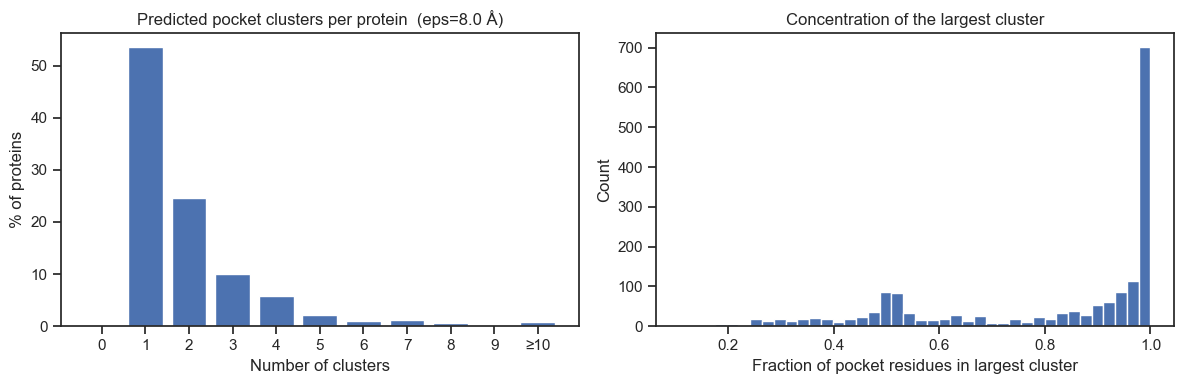

1 cluster  : 53.5%
2–3 clusters: 34.5%
> 3 clusters: 11.6%
median largest-cluster fraction: 0.94


In [8]:
from sklearn.cluster import DBSCAN

CLUSTER_EPS    = 8.0  # Å — residues within this distance are in the same cluster
CLUSTER_MINPTS = 3

n_clusters_per_protein    = []
largest_cluster_frac      = []

for pocket_pos in pocket_pos_list:
    if len(pocket_pos) == 0:
        n_clusters_per_protein.append(0)
        continue
    if len(pocket_pos) < CLUSTER_MINPTS:
        n_clusters_per_protein.append(1)
        largest_cluster_frac.append(1.0)
        continue

    cl = DBSCAN(eps=CLUSTER_EPS, min_samples=CLUSTER_MINPTS).fit_predict(pocket_pos)
    n  = len(set(cl) - {-1})
    n_clusters_per_protein.append(n)
    if n > 0:
        largest_cluster_frac.append(np.bincount(cl[cl >= 0]).max() / len(pocket_pos))

n_clusters_arr   = np.array(n_clusters_per_protein)
largest_frac_arr = np.array(largest_cluster_frac)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

max_show = 10
counts = np.bincount(np.clip(n_clusters_arr, 0, max_show), minlength=max_show + 1)
ax1.bar(range(max_show + 1), counts / counts.sum() * 100)
ax1.set_xticks(range(max_show + 1))
ax1.set_xticklabels([str(i) if i < max_show else f'≥{max_show}' for i in range(max_show + 1)])
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('% of proteins')
ax1.set_title(f'Predicted pocket clusters per protein  (eps={CLUSTER_EPS} Å)')

ax2.hist(largest_frac_arr, bins=40, edgecolor='white')
ax2.set_xlabel('Fraction of pocket residues in largest cluster')
ax2.set_ylabel('Count')
ax2.set_title('Concentration of the largest cluster')

plt.tight_layout()
plt.show()

print(f"1 cluster  : {(n_clusters_arr == 1).mean()*100:.1f}%")
print(f"2–3 clusters: {((n_clusters_arr >= 2) & (n_clusters_arr <= 3)).mean()*100:.1f}%")
print(f"> 3 clusters: {(n_clusters_arr > 3).mean()*100:.1f}%")
print(f"median largest-cluster fraction: {np.median(largest_frac_arr):.2f}")

In [9]:
from sklearn.cluster import DBSCAN

CLUSTER_EPS    = 8.0
CLUSTER_MINPTS = 3
DCA_THRESHOLDS = [4, 6, 8]

hits  = {t: 0 for t in DCA_THRESHOLDS}
total = 0

for entry, pocket_pos in zip(tqdm(entries), pocket_pos_list):
    ligand_path = entry / 'ligand.mol2'
    if not ligand_path.exists() or len(pocket_pos) == 0:
        continue
    try:
        ligand_pos = parse_mol2_coords(ligand_path).numpy()
    except Exception:
        continue

    # one centroid per cluster
    if len(pocket_pos) < CLUSTER_MINPTS:
        centroids = [pocket_pos.mean(axis=0)]
    else:
        cl = DBSCAN(eps=CLUSTER_EPS, min_samples=CLUSTER_MINPTS).fit_predict(pocket_pos)
        cluster_ids = [i for i in set(cl) if i >= 0]
        if not cluster_ids:
            continue
        centroids = [pocket_pos[cl == i].mean(axis=0) for i in cluster_ids]

    # success if ANY cluster centroid is within threshold of ANY ligand atom
    centroid_arr = np.stack(centroids)                                          # (K, 3)
    dists = np.linalg.norm(centroid_arr[:, None] - ligand_pos[None], axis=-1)  # (K, L)
    min_dist_per_cluster = dists.min(axis=1)                                    # (K,)

    total += 1
    for t in DCA_THRESHOLDS:
        if (min_dist_per_cluster < t).any():
            hits[t] += 1

print(f"proteins evaluated : {total}\n")
for t in DCA_THRESHOLDS:
    print(f"  DCA < {t} Å  :  {100*hits[t]/total:.1f}%  ({hits[t]}/{total})")

  0%|          | 0/1752 [00:00<?, ?it/s]

proteins evaluated : 1747

  DCA < 4 Å  :  64.7%  (1131/1747)
  DCA < 6 Å  :  79.2%  (1384/1747)
  DCA < 8 Å  :  86.7%  (1514/1747)
